In [1]:
fig_num = 5 # change this to the figure number
analysis_name = "mpfc_cellType" # change this to the subfolder it should save to

In [2]:
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

# Define Data Files/Paths
subject = "wilbur"
date = "20210406"
file_name = subject + date
nwb_file_name = file_name + "_.nwb"

from spyglass.decoding.v1.c3po import Model
import matplotlib.pyplot as plt

if date == "20210404":
    marks_group_name = "mpfc1"
else:
    marks_group_name = "mpfc"

marks_group_name = marks_group_name + "_HYBRID"


model_key = {
    "nwb_file_name": nwb_file_name,
    "marks_group_name": marks_group_name,
    "training_params_name":"wilbur_post_fix"
}
analysis = (Model() & model_key).fetch_c3po_analysis(model_key, checkpoint=6)


from c3po.analysis.analysis import figure_directory
from pathlib import Path
first_epochs = False
fig_dir = Path(figure_directory) / f"Fig{fig_num}/{analysis_name}"/f"{subject}_{date}_{marks_group_name}"
if first_epochs:
    fig_dir = fig_dir / f"first_{first_epochs}_epochs"
fig_dir.mkdir(parents=True, exist_ok=True)

/home/sambray/.local/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-09-30 10:09:11,526][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python

x shape (1, 34)
x shape (1, 32)


2026-09-30 10:09:31.713197: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-09-30 10:09:33.520371: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-09-30 10:09:35.480977: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
[2026-09-30 10:09:52,738][WARNING]: Skipped checksum for file

In [3]:
from spyglass.common import IntervalList
interval_query = IntervalList & (Model & model_key).proj(interval_list_name="training_interval_name")
run_epochs = interval_query.fetch1("valid_times")

t_interp = [np.arange(start, end, 0.0002) for start, end in run_epochs]
t_interp = np.concatenate(t_interp)
t_interp.shape
analysis.interpolate_context(t_interp)
# analysis.embed_context_pca()

if first_epochs:
    run_epochs = run_epochs[:first_epochs]
analysis.fit_context_pca(fit_intervals = run_epochs)

# Load Data

### Trial and decoding dataframes

In [4]:
from utils.load_mpfc_data import fetch_behavioral_data, fetch_dio_times, fetch_decoding_df

behave_df_set = fetch_behavioral_data(nwb_file_name)
trial_df = behave_df_set["trial_df"]
alison_df = behave_df_set["alison_df"]

dio_intervals = fetch_dio_times(nwb_file_name)
all_pump_intervals = dio_intervals["all_pump_intervals"]
all_poke_intervals = dio_intervals["all_poke_intervals"]

decoding_df = fetch_decoding_df(nwb_file_name)


[10:13:38][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
	Use instead: table.fetch_nwb() method (logic integrated into FetchMixin)
[10:13:38][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use instead: FetchMixin.fetch_nwb() (logic integrated into mixin)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older 

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Devic

### Position Data

In [5]:
# =========================================================
# POSITION / SPEED
# =========================================================
from spyglass.common import IntervalPositionInfo
from c3po.analysis.analysis import interval_list_contains_ind
key = {"nwb_file_name": nwb_file_name}

pos_key = {
    "nwb_file_name": nwb_file_name,
    # "interval_list_name": "pos 1 valid times",
    "position_info_param_name": "default",
}
query = IntervalPositionInfo & pos_key
pos_df = []
st_times = []
for k in query.fetch("KEY"):
    print(k)
    pos_df.append((IntervalPositionInfo & k).fetch1_dataframe())
    st_times.append(pos_df[-1].index.values[0])
st_times = np.array(st_times)
ind = np.argsort(st_times)
pos_df = [pos_df[i] for i in ind]
pos_df = pd.concat(pos_df)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 0 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 1 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 10 valid times'}


...

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 8 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 9 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


### Sorted Spikes

In [6]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

key = {"nwb_file_name": nwb_file_name}
spikes_query = SortedSpikesGroup() & key
spikes_key = spikes_query.fetch1("KEY")
spikes, unit_ids = (spikes_query).fetch_spike_data(spikes_key, return_unit_ids=True)
unit_ids = np.array([f"{u['spikesorting_merge_id']}_{u['unit_id']}" for u in unit_ids])

[10:15:08][WARNING] Spyglass: Missing code for CurationV2


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Devic

In [7]:
from spyglass.spikesorting.spikesorting_merge import SpikeSortingOutput
from spyglass.spikesorting.v0 import SpikeSorterParameters

q = (spikes_query.Units & spikes_query).proj(merge_id = "spikesorting_merge_id")
q = SpikeSortingOutput.CuratedSpikeSorting & q
(SpikeSorterParameters & q).fetch1()

{'sorter': 'mountainsort4',
 'sorter_params_name': 'franklab_probe_ctx_30KHz_115rad_new_mountainsort2',
 'sorter_params': {'detect_sign': -1,
  'adjacency_radius': 115,
  'freq_min': 300,
  'freq_max': 6000,
  'filter': False,
  'whiten': True,
  'num_workers': 1,
  'clip_size': 40,
  'detect_threshold': 3,
  'detect_interval': 10,
  'verbose': True}}

## Load monosynaptic results

In [33]:
import os
os.chdir("/home/sambray/Documents/spyglass_custom/src/spyglass_custom/sambray")
from monosynaptic import Monosynaptic, MonosynapticParams
from cross_correlogram import CrossCorrelogram, ShuffleCrossCorrelogram

mono_params = "default"
mono_key = (Monosynaptic & spikes_key & {"monosynaptic_params_name": mono_params}).fetch1("KEY")
neuron_types = (Monosynaptic & mono_key).get_neuron_types()
mono_df = (Monosynaptic & mono_key).fetch1_dataframe()


# all_reciprical = []
# valid = []
# for id in neuron_types["inhibitory"]:
#     downstream_ids = mono_df[mono_df.unit_id_2 ==id].unit_id_1.values

#     recip_df = mono_df[mono_df.unit_id_2.isin(downstream_ids) & (mono_df.unit_id_1 == id)]
#     if len(recip_df) == len(downstream_ids):
#         all_reciprical.append(recip_df)
#     else:
#         valid.append(id)
# print(len(all_reciprical))
# print(len(valid))
# neuron_types["inhibitory"] = valid
ambiguous = np.intersect1d(neuron_types["excitatory"], neuron_types["inhibitory"])
neuron_types["excitatory"] = np.array([i for i in neuron_types["excitatory"] if i not in ambiguous])
neuron_types["inhibitory"] = np.array([i for i in neuron_types["inhibitory"] if i not in ambiguous])
print(f"Ambiguous neurons: {ambiguous}")


corr_df = (CrossCorrelogram & spikes_key & {"cross_corr_params_name":"monosynaptic"}).fetch1_dataframe()
shuffle_corr_df = (ShuffleCrossCorrelogram & spikes_key).fetch1_dataframe()
corr_df = corr_df.merge(shuffle_corr_df, on=["unit_id_1", "unit_id_2"], suffixes=("", "_shuffle"))
ind_neuron_type = {}
for type_, ids_ in neuron_types.items():
    ind_neuron_type[type_] = [np.where(unit_ids == i)[0][0] for i in ids_]
neuron_colors = {
    "excitatory": "cornflowerblue",
    "inhibitory":"firebrick"
}
corr_broad_df = (CrossCorrelogram & spikes_key & {"cross_corr_params_name":"reciprocal_analysis"}).fetch1_dataframe()

Ambiguous neurons: ['3a02e829-53d0-9dbf-0667-a44681becc44_92'
 '603ed441-252e-8393-270c-88a10f78b723_21'
 '603ed441-252e-8393-270c-88a10f78b723_26'
 '603ed441-252e-8393-270c-88a10f78b723_66'
 '940057ae-a68d-1236-9105-1b08c3c6db5b_16'
 '940057ae-a68d-1236-9105-1b08c3c6db5b_9'
 'b961ffc8-147a-6742-39a4-8b2950461d95_52'
 'b961ffc8-147a-6742-39a4-8b2950461d95_76'
 'eeabd812-8ace-5292-edf6-05c925a8b427_5'
 'efb8b6c7-4482-069c-78ba-55a5e52a92a3_28']


[2026-09-30 13:31:01,319][WARNING]: Skipped checksum for file with hash: 049a144d-57f2-8ecb-9ed5-17a66f88e9fa, and path: /stelmo/nwb/analysis/wilbur20210406/wilbur20210406_TA2HCL9J4Y.nwb
[2026-09-30 13:31:01,331][WARNING]: Skipped checksum for file with hash: 049a144d-57f2-8ecb-9ed5-17a66f88e9fa, and path: /stelmo/nwb/analysis/wilbur20210406/wilbur20210406_TA2HCL9J4Y.nwb


In [26]:
mono_df
neuron_types
all_reciprical = []
valid = []
for id in neuron_types["inhibitory"]:
    downstream_ids = mono_df[mono_df.unit_id_2 ==id].unit_id_1.values

    recip_df = mono_df[mono_df.unit_id_2.isin(downstream_ids) & (mono_df.unit_id_1 == id)]
    if len(recip_df) == len(downstream_ids):
        all_reciprical.append(recip_df)
    else:
        valid.append(id)

print(len(all_reciprical))
print(len(valid))

8
17


# Analyze

## Population Differences

In [34]:
z_neuron = analysis.params['params']['embedding']['encoder']['sorted_encoder']['encoder_matrix']
z_neuron = z_neuron @ analysis.pca.components_.T

15
115


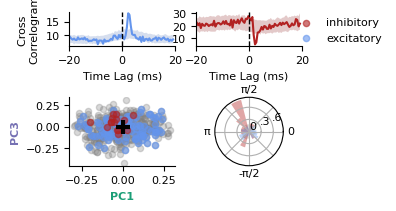

In [63]:
pc_plot = (0,2)


plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['font.size'] = 8
# fig, ax = plt.subplots(ncols=2, figsize=(4,4))


# fig = plt.figure(figsize=(3,3))
# # ax1 = fig.add_subplot(3,2, 1)
# # ax2 = fig.add_subplot(3,2, 2, projection='polar')
# # ex_ax = fig.add_subplot(3,1, 2)
# # in_ax = fig.add_subplot(3,1, 3, sharex=ex_ax)
# ax1 = fig.add_subplot(2,2, 1)
# ax2 = fig.add_subplot(2,2, 2, projection='polar')
# ex_ax = fig.add_subplot(2,2, 3)
# in_ax = fig.add_subplot(2,2, 4, sharex=ex_ax)
# fig.subplots_adjust(hspace=0.4)

fig = plt.figure(figsize=(3,2))
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1,2],   # top row : bottom row
    hspace=1
)

ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1], projection='polar')

ex_ax = fig.add_subplot(gs[0, 0])
in_ax = fig.add_subplot(gs[0, 1], sharex=ex_ax)

scatter_size = 20

z_plot = z_neuron[:, pc_plot]
z_angle = np.arctan2(z_plot[:,1], z_plot[:,0])
angle_bins = np.linspace(-np.pi, np.pi, 20)


ax1.scatter(z_plot[:,0], z_plot[:,1], c="grey",alpha = .3, s=scatter_size)
ax2.hist(z_angle, bins=angle_bins, color="grey", alpha=0.3, density=True)

for type_, inds_ in ind_neuron_type.items():
    print(len(inds_))
    ax1.scatter(z_plot[inds_,0], z_plot[inds_,1], label=type_, color=neuron_colors[type_],
                alpha=0.6,zorder=10 if type_=="inhibitory" else 5, s=scatter_size)
    ax2.hist(z_angle[inds_], bins=angle_bins, color=neuron_colors[type_], alpha=0.4, density=True)


c1 = plt.cm.Dark2(pc_plot[0]/8)
c2 = plt.cm.Dark2(pc_plot[1]/8)
ax1.set_xlabel(f"PC{pc_plot[0]+1}", color=c1,fontweight="bold")
ax1.set_ylabel(f"PC{pc_plot[1]+1}", color=c2,fontweight="bold")
# ax1.set_title("Neuron Embedding")
# ax2.set_title("Neuron Embedding Angle")
ax1.spines[["top", "right"]].set_visible(False)
ax2.set_rticks([0,.3,.6])
ax1.scatter(0,0,c="k",s=100,marker="+",zorder=15,lw=3)
fig.legend(frameon=False, bbox_to_anchor=(1.2, .9), )


unit_id_2 = "3a02e829-53d0-9dbf-0667-a44681becc44_92"
unit_id_1 = "efb8b6c7-4482-069c-78ba-55a5e52a92a3_58"
corr_row = corr_df.query("unit_id_1 == @unit_id_1 and unit_id_2 == @unit_id_2")
bins = np.array(corr_row["bins"].values[0])*1000
corr = np.array(corr_row["correlogram"].values[0])
lb = np.array(corr_row["lower_bound"].values[0])
ub = np.array(corr_row["upper_bound"].values[0])
color = neuron_colors["inhibitory"]
in_ax.plot(bins, corr, color=color)
in_ax.fill_between(bins, lb, ub, facecolor=color, alpha=0.2)
in_ax.fill_between(bins, lb, ub, facecolor="grey", alpha=0.1)
ind_unit_2 = np.where(unit_ids == unit_id_2)[0][0]
ind_unit_1 = np.where(unit_ids == unit_id_1)[0][0]

unit_id_2 = "603ed441-252e-8393-270c-88a10f78b723_18"
unit_id_1 = "603ed441-252e-8393-270c-88a10f78b723_34"
corr_row = corr_df.query("unit_id_1 == @unit_id_1 and unit_id_2 == @unit_id_2")
bins = np.array(corr_row["bins"].values[0])*1000
corr = np.array(corr_row["correlogram"].values[0])
lb = np.array(corr_row["lower_bound"].values[0])
ub = np.array(corr_row["upper_bound"].values[0])
color = neuron_colors["excitatory"]
ex_ax.plot(bins, corr, color=color)
ex_ax.fill_between(bins, lb, ub, facecolor=color, alpha=0.2)
ex_ax.fill_between(bins, lb, ub, facecolor="grey", alpha=0.1)
ind_unit_2 = np.where(unit_ids == unit_id_2)[0][0]
ind_unit_1 = np.where(unit_ids == unit_id_1)[0][0]

# in_ax.set_xlim(-15,15)
in_ax.set_xlim(-20,20)
ex_ax.set_ylabel("Cross \nCorrelogram")
for a in [ex_ax, in_ax]:
    a.spines[["top", "right"]].set_visible(False)
    a.axvline(0, color="k", ls="--", lw=1)
    a.set_xlabel("Time Lag (ms)")

ax2.set_xticks([0,
                np.pi/4,
                np.pi/2,
                3*np.pi/4,
                np.pi,
                5*np.pi/4,
                3*np.pi/2,
                7*np.pi/4],
)
ax2.set_xticklabels(
               labels=["0", "", "π/2", "", "π", "", "-π/2", ""],
)
ax2.set_yticks([0, .3, .6])
ax2.set_yticklabels(
    labels=["0", ".3", ".6"],
)
ax2.tick_params(axis="x", pad=-5)
fig.savefig(fig_dir / f"celltype_embedding_plus_traces.svg")

In [50]:
fig_dir

PosixPath('/home/sambray/Documents/c3po/Figures/Fig5/mpfc_cellType/wilbur_20210406_mpfc_HYBRID')

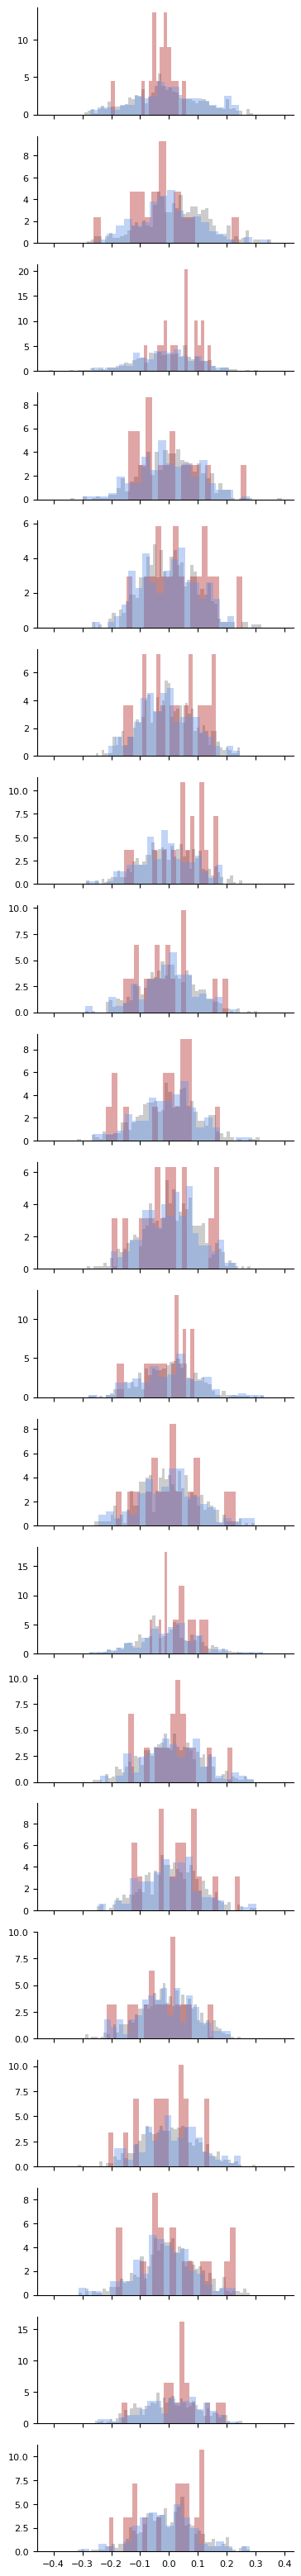

In [29]:
n_pc = 20
fig, ax = plt.subplots(nrows=n_pc,  figsize=(4,2*n_pc),sharex=True)

for i in range(n_pc):
    ax[i].hist(z_neuron[:,i], bins=50, color="grey", alpha=0.4, density=True)
    for type_, inds_ in ind_neuron_type.items():
        ax[i].hist(z_neuron[inds_,i], bins=20, color=neuron_colors[type_], alpha=0.4, density=True)

## Monosynaptic Pairs

- Identify nice inhibitory monosynaptic pair from correlograms
- Compare embeddings
- Get aligned response to spike times of the inhibitory neuron (unit_id_2)
- Look at predicted firing rate of the downstream neuron (alligned_response @ z_neuron_1)
- compare to the correlogram

### Pairwise plot examples

 29%|██▉       | 20/69 [00:03<00:08,  5.73it/s]/tmp/ipykernel_1935084/2159806371.py:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8,4),sharex=True)
 54%|█████▎    | 37/69 [00:08<00:07,  4.54it/s]


KeyboardInterrupt: 

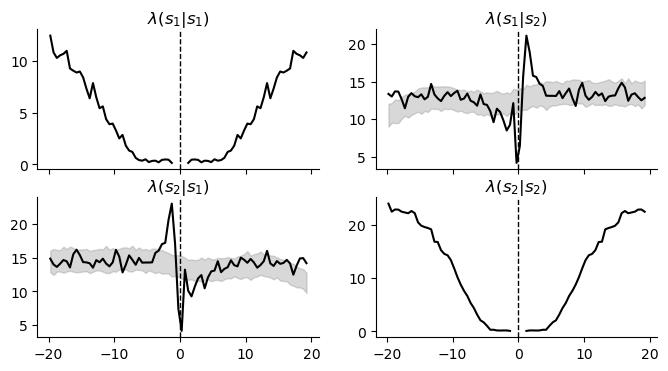

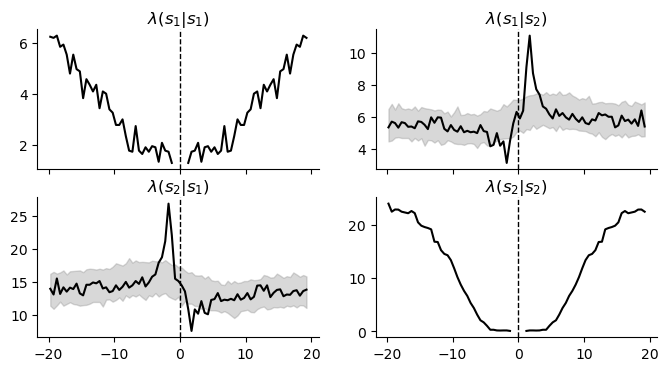

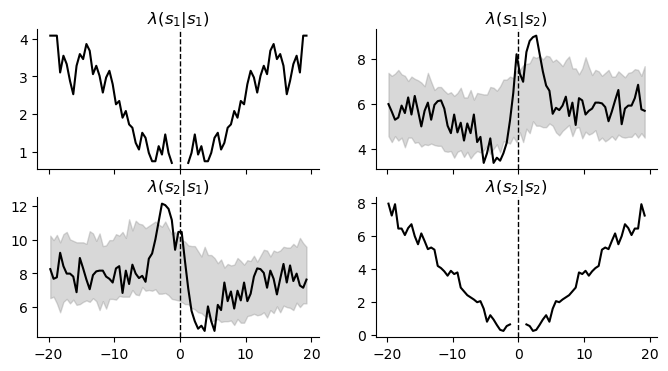

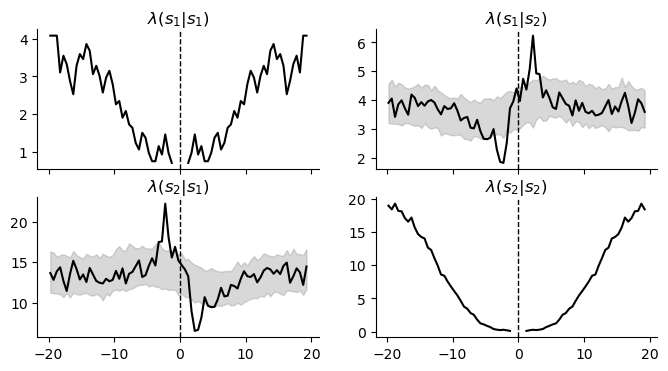

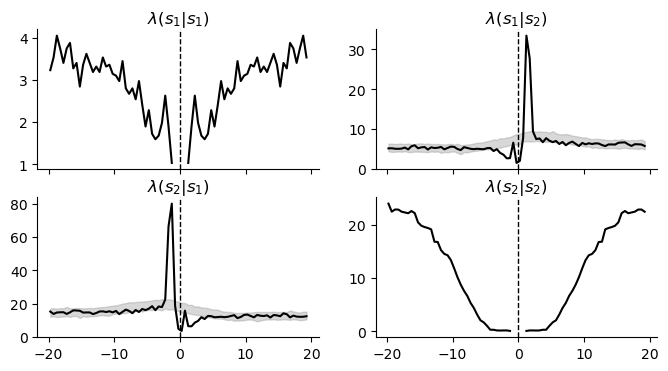

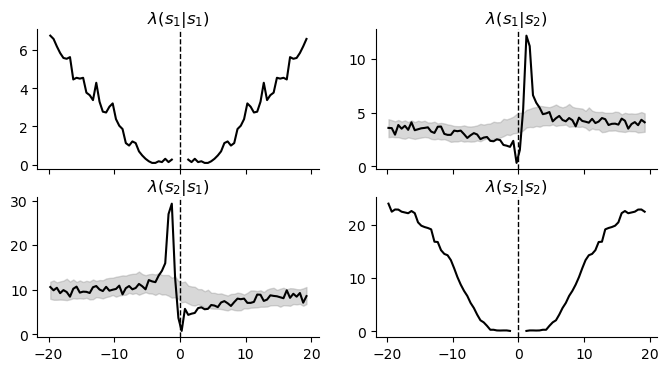

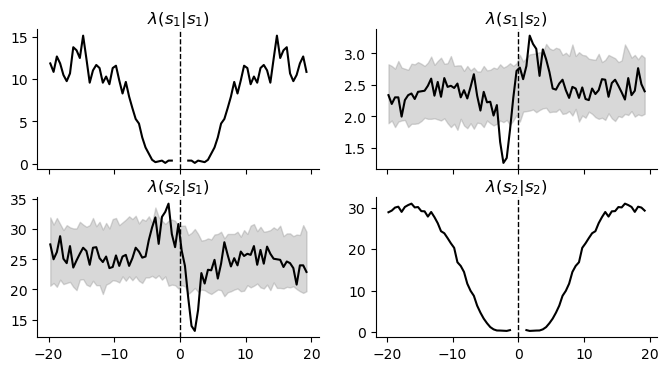

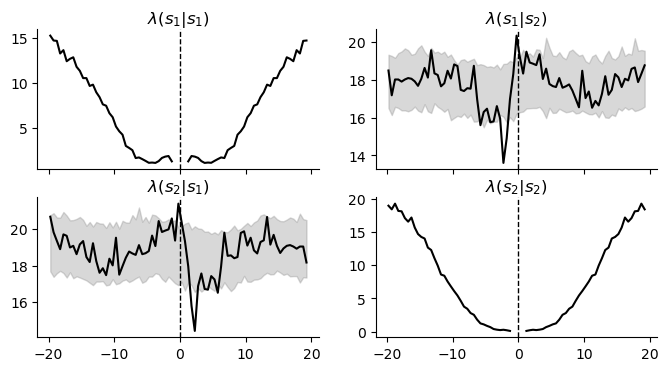

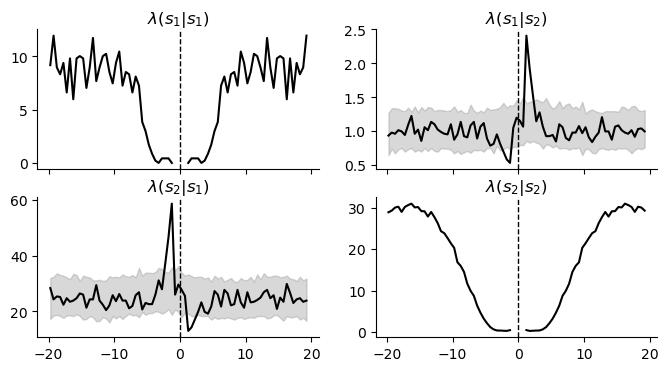

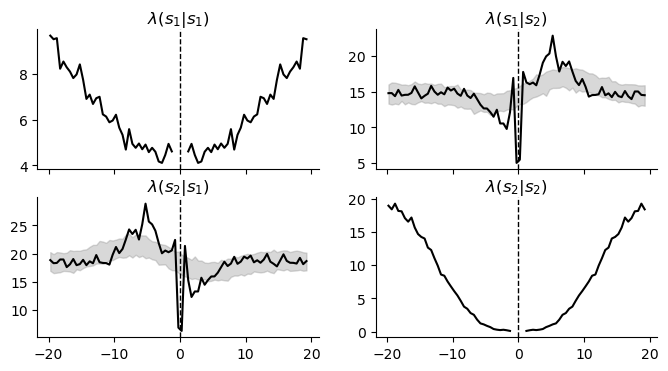

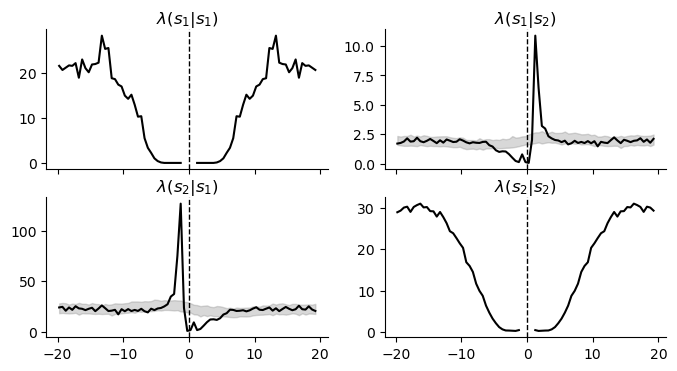

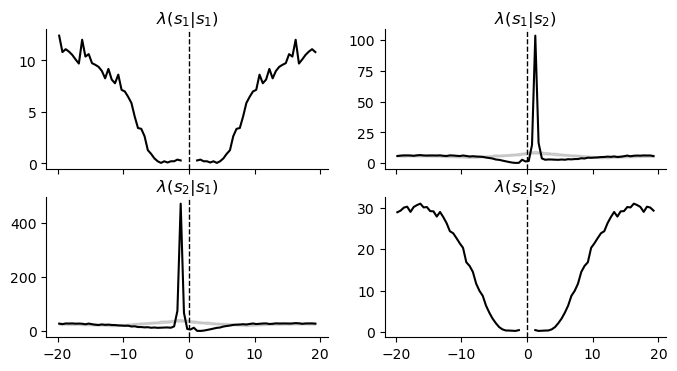

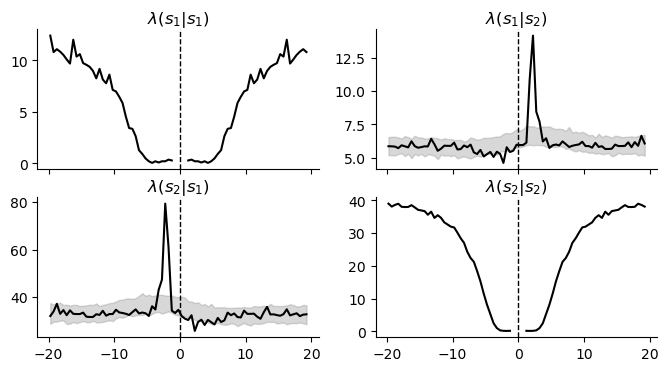

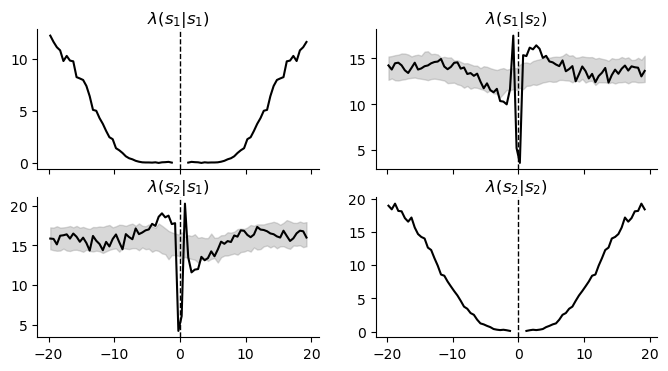

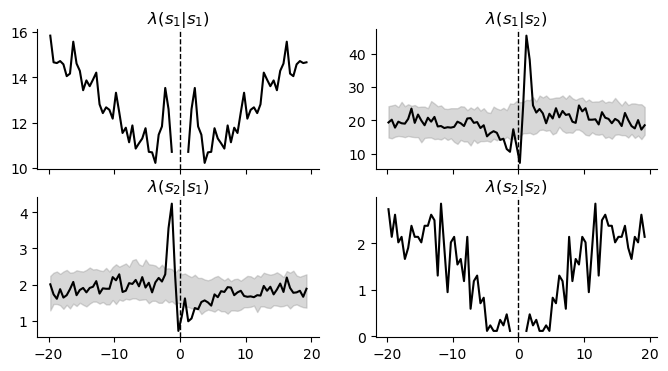

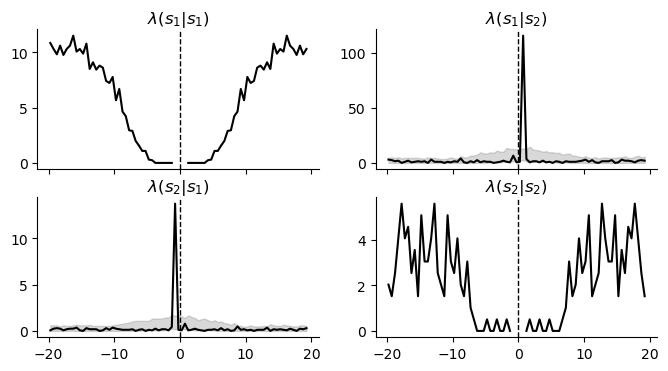

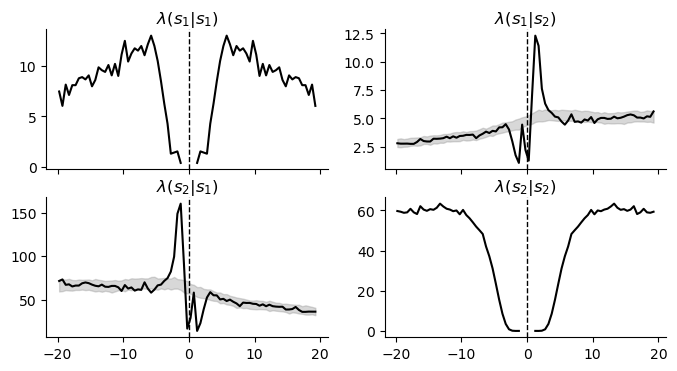

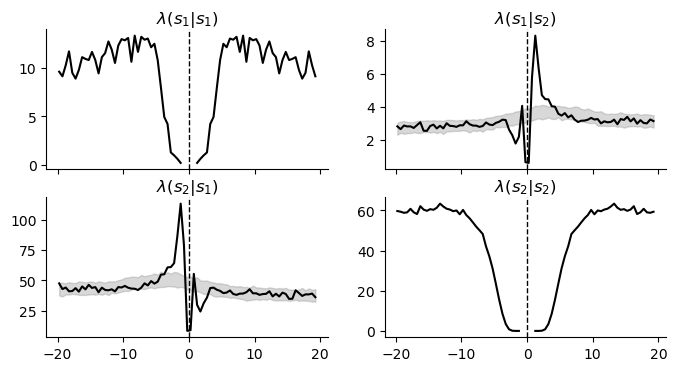

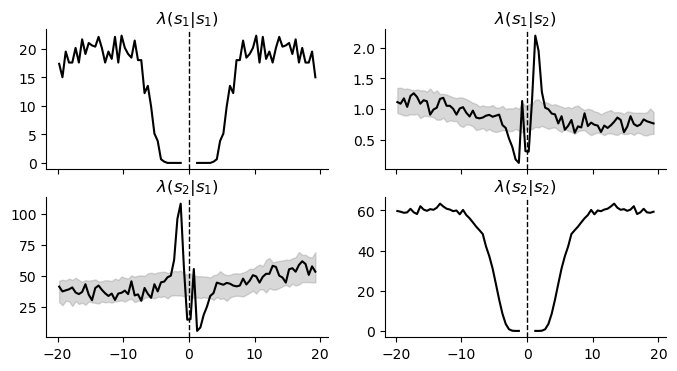

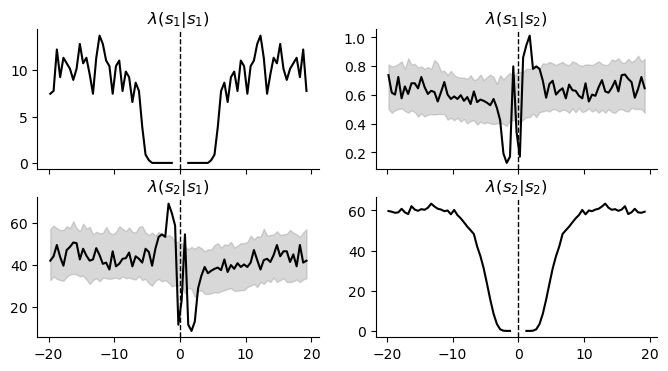

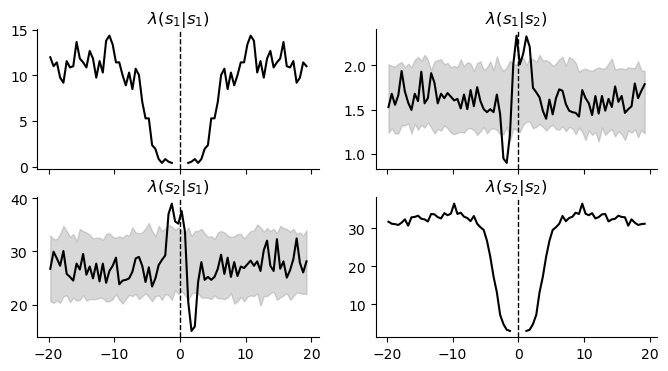

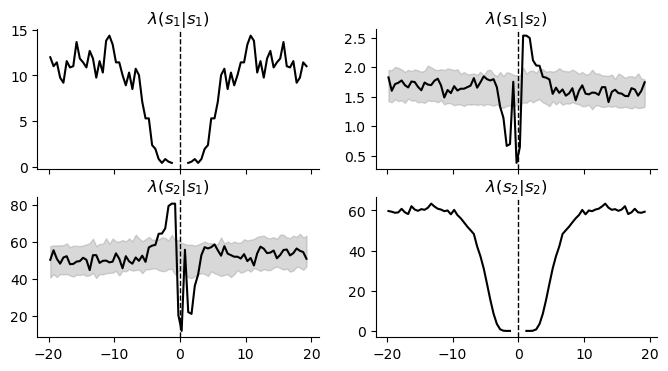

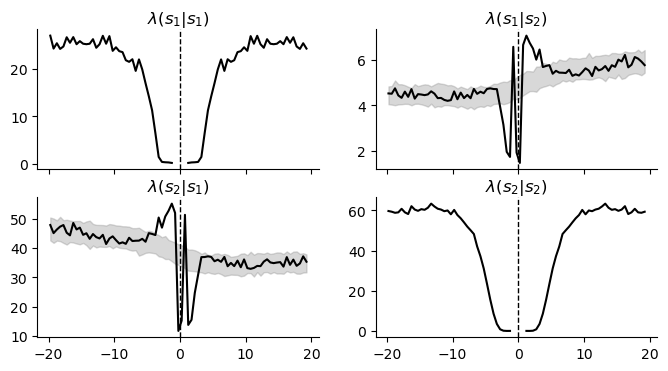

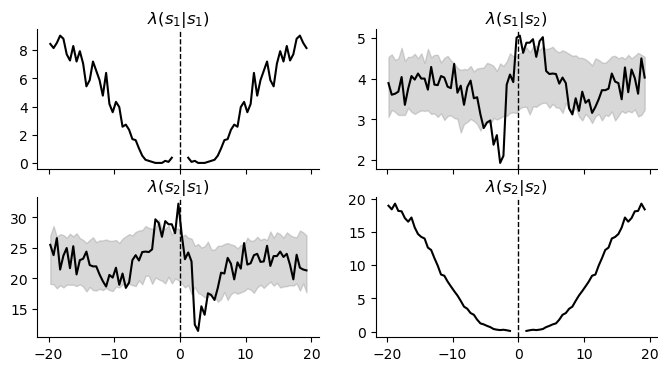

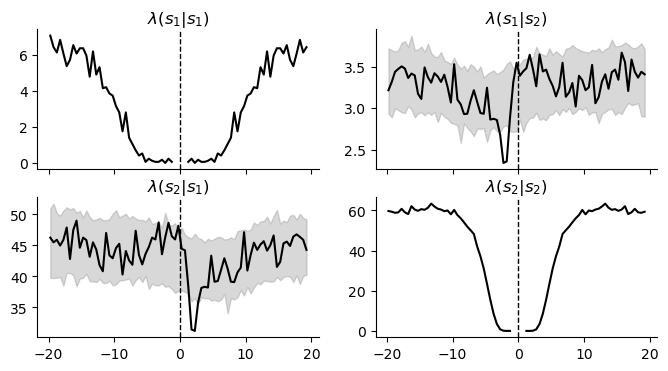

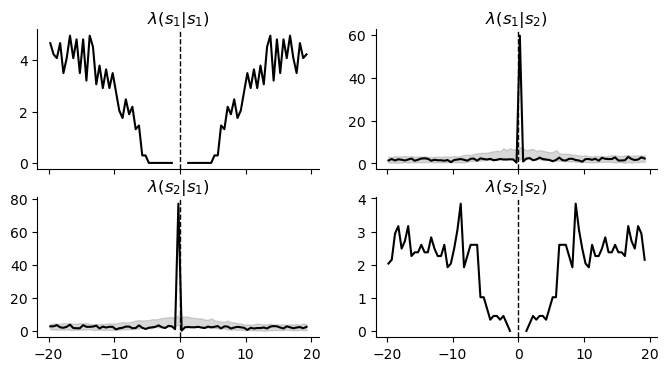

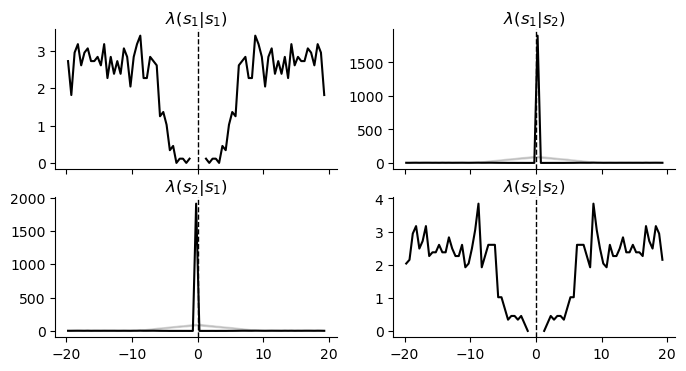

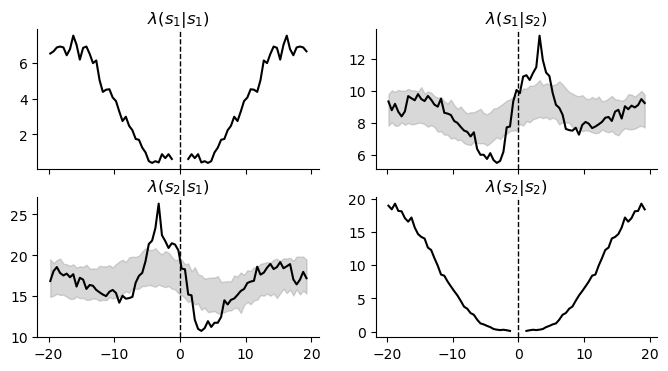

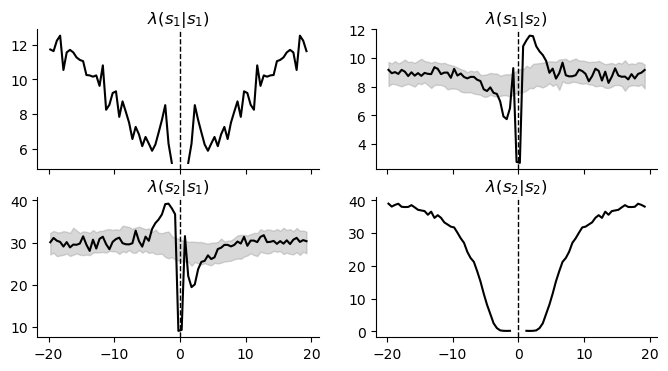

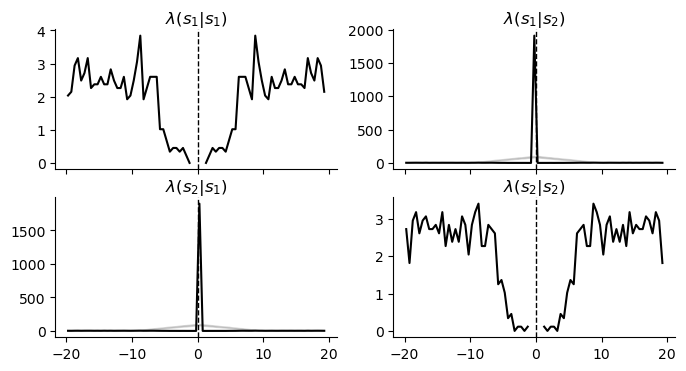

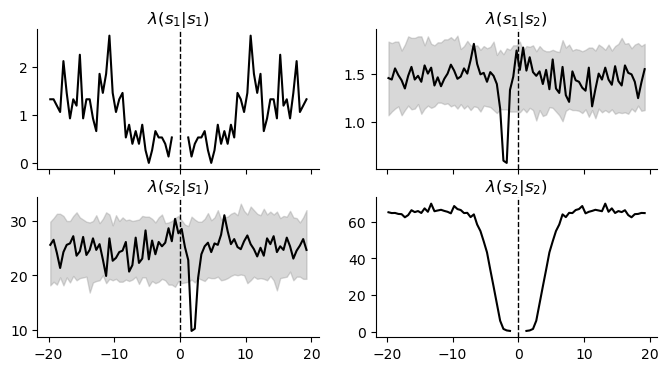

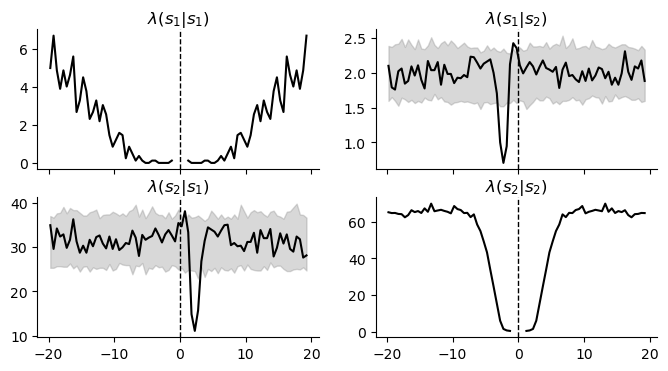

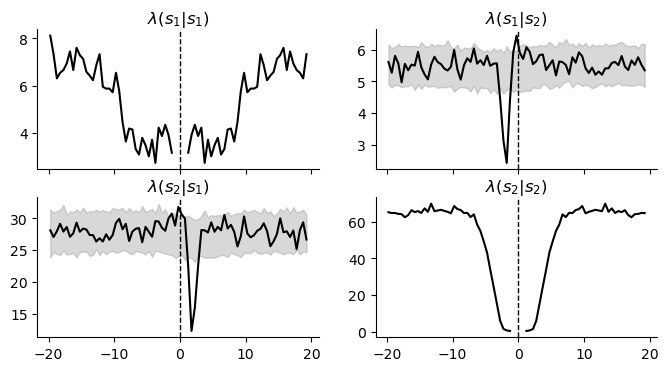

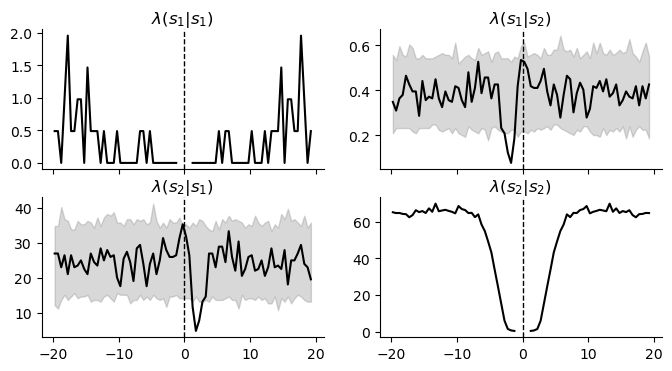

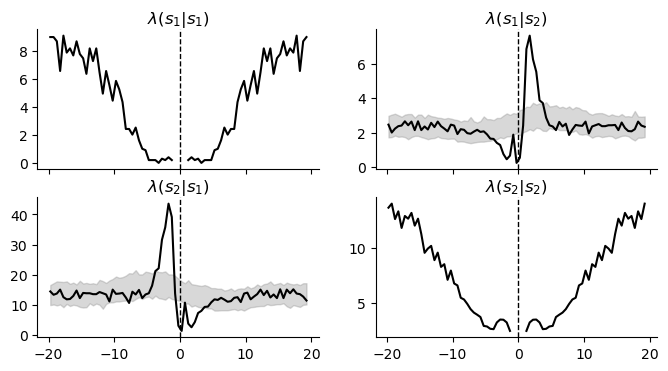

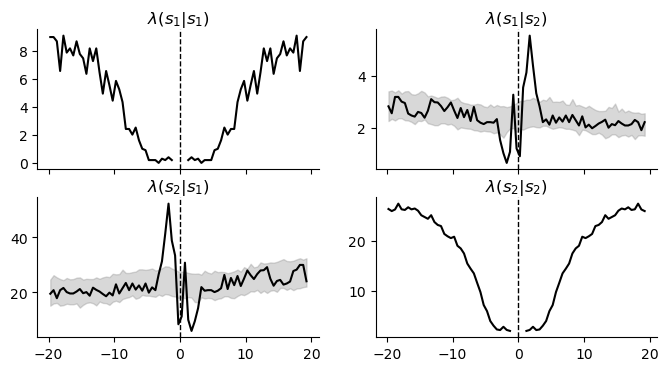

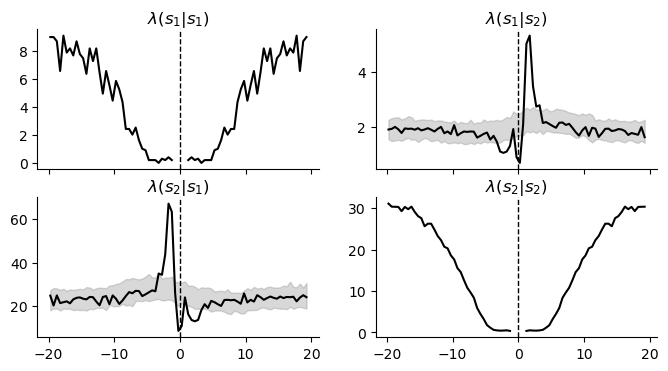

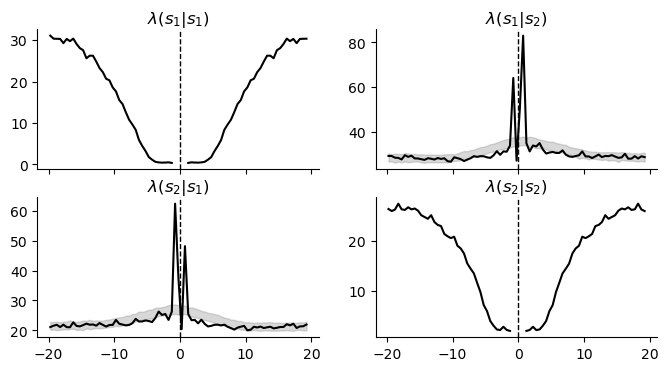

In [ ]:
i_pair = 1
# i_pair = 3 # Great example of inhibitory pair
# i_pair = 12
i_pair = 32

inhibitory_pairs = mono_df.query("interaction == 'inhibitory'")
# unit_id_1 = inhibitory_pairs.iloc[i_pair]["unit_id_1"]
# unit_id_2 = inhibitory_pairs.iloc[i_pair]["unit_id_2"]

# excitatory_pairs = mono_df.query("interaction == 'excitatory'")
# unit_id_1 = excitatory_pairs.iloc[i_pair]["unit_id_1"]
# unit_id_2 = excitatory_pairs.iloc[i_pair]["unit_id_2"]

entry_sets = [(1, 1),  (2, 1), (1, 2),(2, 2)]

from tqdm import tqdm
to_do = np.arange(len(inhibitory_pairs))
# to_do = [13]
for i_pair in tqdm(to_do):
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8,4),sharex=True)


    for i, (entry_1, entry_2) in enumerate(entry_sets):
        # unit_id_1 = inhibitory_pairs.iloc[i_pair]["unit_id_1"]
        # unit_id_2 = inhibitory_pairs.iloc[i_pair]["unit_id_2"]
        # if entry_1 == 2:
        #     unit_id_1 = inhibitory_pairs.iloc[i_pair]["unit_id_2"]
        # if entry_2 == 2:
        #     unit_id_2 = inhibitory_pairs.iloc[i_pair]["unit_id_1"]
        pair = inhibitory_pairs.iloc[i_pair]
        unit_id_1 = pair[f"unit_id_{entry_1}"]
        unit_id_2 = pair[f"unit_id_{entry_2}"]
        corr_row = corr_df.query("unit_id_1 == @unit_id_1 and unit_id_2 == @unit_id_2")


        ax_i = ax[entry_2-1, entry_1-1]
        bins = np.array(corr_row["bins"].values[0])*1000
        corr = np.array(corr_row["correlogram"].values[0])
        lb = np.array(corr_row["lower_bound"].values[0])
        ub = np.array(corr_row["upper_bound"].values[0])
        # plt.sca(ax_i)

        ax_i.set_title(f"$\\lambda(s_{entry_2} | s_{entry_1})$", pad=0)

        if entry_1 == entry_2:
            ind_bad = np.where(np.abs(bins)<1)[0]
            corr[ind_bad] = np.nan
            lb[ind_bad] = np.nan
            ub[ind_bad] = np.nan
            lb[:] = np.nan
            ub[:] = np.nan


            # ind_valid = np.where(np.abs(bins)>2)[0]
        # else:
        #     ind_valid = np.arange(len(bins))


        ax_i.plot(bins, corr, color="k")
        ax_i.fill_between(bins, lb, ub, color="grey", alpha=0.3)
        ind_unit_2 = np.where(unit_ids == unit_id_2)[0][0]
        ind_unit_1 = np.where(unit_ids == unit_id_1)[0][0]

    for a in ax.flatten():
        a.axvline(0, color="k", ls="--", lw=1)
        a.spines[["top", "right"]].set_visible(False)
    sub_dir = fig_dir / "inhibitory_pairs"
    sub_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(sub_dir / f"pair_{i_pair}_cross_correlogram.svg")
    plt.close(fig)
# ax[0,0].set_ylim(0,10)
# ax[1,1].set_ylim(0,30)

# ax[0,0].set_ylim(0, ax[0,1].get_ylim()[1])
# ax[0,1].set_ylim(0, ax[0,1].get_ylim()[1])
# ax[1,1].set_ylim(0, ax[1,0].get_ylim()[1])
# ax[1,0].set_ylim(0, ax[1,0].get_ylim()[1])
# ax[0,0].set_title("$\\lambda(s_1 | s_1)$")
# ax[1,1].set_title("$\\lambda(s_2 | s_2)$")
# ax[0,1].set_title("$\\lambda(s_1 | s_2)$")
# ax[1,0].set_title("$\\lambda(s_2 | s_1)$")

In [15]:
pair

unit_id_1      b961ffc8-147a-6742-39a4-8b2950461d95_15
unit_id_2      b961ffc8-147a-6742-39a4-8b2950461d95_50
interaction                                 inhibitory
Name: 212, dtype: object

### Single plot example

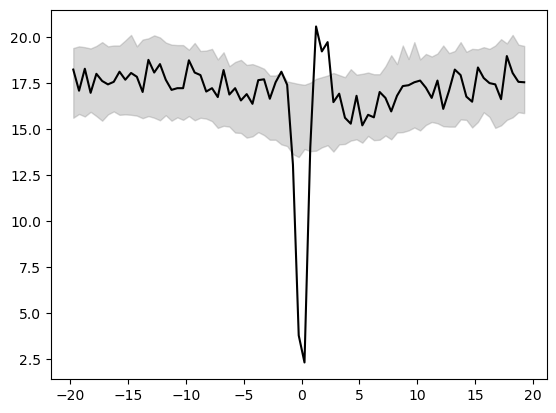

In [24]:
i_pair = 1
i_pair = 3 # Great example of inhibitory pair
i_pair = 12

inhibitory_pairs = mono_df.query("interaction == 'inhibitory'")
unit_id_1 = inhibitory_pairs.iloc[i_pair]["unit_id_1"]
unit_id_2 = inhibitory_pairs.iloc[i_pair]["unit_id_2"]

excitatory_pairs = mono_df.query("interaction == 'excitatory'")
unit_id_1 = excitatory_pairs.iloc[i_pair]["unit_id_1"]
unit_id_2 = excitatory_pairs.iloc[i_pair]["unit_id_2"]

corr_row = corr_df.query("unit_id_1 == @unit_id_1 and unit_id_2 == @unit_id_2")

bins = np.array(corr_row["bins"].values[0])*1000
corr = np.array(corr_row["correlogram"].values[0])
lb = np.array(corr_row["lower_bound"].values[0])
ub = np.array(corr_row["upper_bound"].values[0])
plt.plot(bins, corr, color="k")
plt.fill_between(bins, lb, ub, color="grey", alpha=0.3)
ind_unit_2 = np.where(unit_ids == unit_id_2)[0][0]
ind_unit_1 = np.where(unit_ids == unit_id_1)[0][0]

from c3po.analysis.intervals import interval_list_contains
marks = spikes[ind_unit_2]
marks = interval_list_contains(run_epochs, marks)


0.00020060180541624107 25


100%|██████████| 3/3 [00:01<00:00,  1.96it/s]


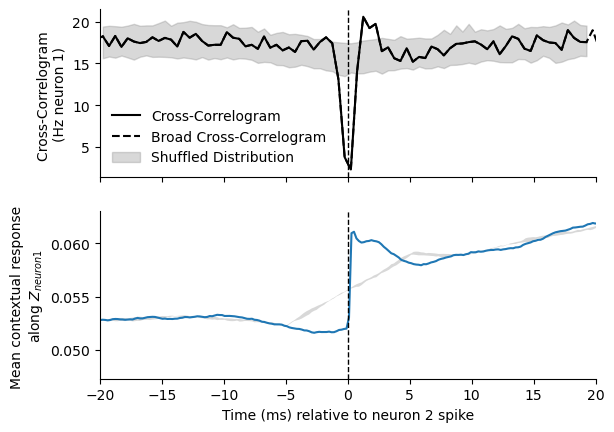

In [26]:
window = -.1,.1
# window = -.25,.25

results = analysis.alligned_response(
    marks,
    window,
    pca=True
)
z_neuron_1 = z_neuron[ind_unit_1]
rate = (results * z_neuron_1[None,None,:]).sum(axis=2)

n_shuffle = 3
shuffle_time = .005

t_plot = np.linspace(window[0], window[1], rate.shape[1])*1000
dt = np.diff(t_plot)[0]/1000
shuffle_bins = np.round(shuffle_time/dt).astype(int)
print(dt, shuffle_bins)

shuffle_rate = np.empty((n_shuffle, rate.shape[1]))

from tqdm import tqdm
for i_shuffle in tqdm(range(n_shuffle)):
    shuffle_amounts = np.random.randint(-shuffle_bins, shuffle_bins+1, size=rate.shape[0])
    rate_i = np.array(rate)
    for j in range(-shuffle_bins, shuffle_bins+1):
        if j == 0:
            continue
        ind = np.where(shuffle_amounts == j)[0]
        rate_i[ind] = np.roll(rate_i[ind], j, axis=1)
    shuffle_rate[i_shuffle] = rate_i.mean(axis=0)
fig, ax = plt.subplots(nrows=2,sharex=True)
corr_ax = ax[0]
c3po_ax = ax[1]

corr_row = corr_df.query("unit_id_1 == @unit_id_1 and unit_id_2 == @unit_id_2")
corr_row_broad = corr_broad_df.query("unit_id_1 == @unit_id_1 and unit_id_2 == @unit_id_2")

bins = np.array(corr_row["bins"].values[0])*1000
corr = np.array(corr_row["correlogram"].values[0])
bins_broad = np.array(corr_row_broad["bins"].values[0])*1000
corr_broad = np.array(corr_row_broad["correlogram"].values[0])

lb = np.array(corr_row["lower_bound"].values[0])
ub = np.array(corr_row["upper_bound"].values[0])
ax[0].plot(bins, corr, color="k", label="Cross-Correlogram")
ax[0].plot(bins_broad, corr_broad, color="k", ls="--", label="Broad Cross-Correlogram")
ax[0].fill_between(bins, lb, ub, color="grey", alpha=0.3, label="Shuffled Distribution")
ax[0].legend(frameon=False)

t_plot = np.linspace(window[0], window[1], rate.shape[1])*1000
ax[1].plot(t_plot,rate.mean(axis=0),)
lb = np.min(shuffle_rate, axis=0)
ub = np.max(shuffle_rate, axis=0)
ax[1].fill_between(t_plot, lb, ub, facecolor="grey", alpha=0.3)
ax[1].set_xlim(-20,20)
# ax[1].set_xlim(-60,60)

ax[0].set_ylabel("Cross-Correlogram \n(Hz neuron 1)")
ax[1].set_ylabel("Mean contextual response \nalong $Z_{neuron 1}$")
ax[1].set_xlabel("Time (ms) relative to neuron 2 spike")

# ax[0].set_yscale("log")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
    a.axvline(0, color="k", ls="--", lw=1)

# Screen

In [38]:
from __future__ import annotations

from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


def compute_circular_shuffle_bounds(
    rate: np.ndarray,
    n_shuffle: int,
    shuffle_bins: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute bounds of independently circularly shifted event responses.

    Each event receives an independently sampled circular time shift for each
    shuffle. Events assigned the same shift are aggregated using matrix
    multiplication.

    Parameters
    ----------
    rate : np.ndarray, shape (n_events, n_time)
        Projected responses for each aligned event.
    n_shuffle : int
        Number of shuffled means to generate.
    shuffle_bins : int
        Maximum circular shift in bins in either direction.
    rng : np.random.Generator
        Random-number generator.

    Returns
    -------
    lower_bound : np.ndarray, shape (n_time,)
        Minimum shuffled mean at each time bin.
    upper_bound : np.ndarray, shape (n_time,)
        Maximum shuffled mean at each time bin.
    """
    rate = np.asarray(rate)

    if rate.ndim != 2:
        raise ValueError(
            "`rate` must have shape (n_events, n_time). "
            f"Received shape {rate.shape}."
        )

    n_events, n_time = rate.shape

    if n_events == 0:
        nan_bound = np.full(n_time, np.nan)
        return nan_bound.copy(), nan_bound.copy()

    shift_values = np.arange(
        -shuffle_bins,
        shuffle_bins + 1,
        dtype=np.int64,
    )
    n_shift_values = shift_values.size

    # Shape: (n_shuffle, n_events)
    shift_assignments = rng.integers(
        0,
        n_shift_values,
        size=(n_shuffle, n_events),
    )

    work_dtype = np.result_type(rate.dtype, np.float32)
    rate_work = np.asarray(rate, dtype=work_dtype)

    # Shape: (n_shuffle, n_time)
    shuffled_sums = np.zeros(
        (n_shuffle, n_time),
        dtype=work_dtype,
    )

    for shift_index, shift in enumerate(shift_values):
        # Indicates which events receive this shift in each shuffle.
        # Shape: (n_shuffle, n_events)
        weights = (shift_assignments == shift_index).astype(
            work_dtype,
            copy=False,
        )

        # Shape: (n_events, n_time)
        shifted_rate = np.roll(
            rate_work,
            shift=int(shift),
            axis=1,
        )

        # (n_shuffle, n_events) @ (n_events, n_time)
        shuffled_sums += weights @ shifted_rate

    shuffled_means = shuffled_sums / n_events

    lower_bound = np.min(shuffled_means, axis=0)
    upper_bound = np.max(shuffled_means, axis=0)

    return lower_bound, upper_bound

In [ ]:
interaction = "excitatory"
(fig_dir / f"{interaction}").mkdir(parents=True, exist_ok=True)
window = -.03, .03
n_shuffle = 30
shuffle_time = .005

_pairs = mono_df.query(f"interaction == '{interaction}'")
for unit_id_2 in _pairs["unit_id_2"].unique():
    ind_unit_2 = np.where(unit_ids == unit_id_2)[0][0]
    marks = spikes[ind_unit_2]
    marks = interval_list_contains(run_epochs, marks)
    results = analysis.alligned_response(
        marks,
        window,
        pca=True
    )
    for unit_id_1 in tqdm(_pairs.query("unit_id_2 == @unit_id_2")["unit_id_1"].unique()):
        figname = fig_dir / f"{interaction}/{unit_id_2}_{unit_id_1}.png"
        if figname.exists():
            print(f"Skipping {figname}")
            continue
        ind_unit_1 = np.where(unit_ids == unit_id_1)[0][0]
        z_neuron_1 = z_neuron[ind_unit_1]
        rate = np.einsum(
            "etc,c->et",
            results,
            z_neuron_1,
            optimize=True,
        )
        t_plot = np.linspace(window[0], window[1], rate.shape[1])*1000
        dt = np.diff(t_plot)[0]/1000
        shuffle_bins = np.round(shuffle_time/dt).astype(int)

        # shuffle_rate = np.empty((n_shuffle, rate.shape[1]))
        rng = np.random.default_rng()
        # time_idx = np.arange(rate.shape[1])
        # for i_shuffle in range(n_shuffle):
        #     # one circular shift per unit
        #     shifts = rng.integers(-shuffle_bins, shuffle_bins + 1, size=rate.shape[0])

        #     # For each unit u and time t, pull from t - shift[u]
        #     shifted_idx = (time_idx[None, :] - shifts[:, None]) % rate.shape[1]

        #     # Equivalent to rolling each row independently
        #     rate_i = np.take_along_axis(rate, shifted_idx, axis=1)

        #     shuffle_rate[i_shuffle] = rate_i.mean(axis=0)


        lb_rate, ub_rate =compute_circular_shuffle_bounds(
            rate,
            n_shuffle,
            shuffle_bins,
            rng,
        )








        fig, ax = plt.subplots(nrows=2,sharex=True)
        corr_ax = ax[0]
        c3po_ax = ax[1]

        corr_row = corr_df.query("unit_id_1 == @unit_id_1 and unit_id_2 == @unit_id_2")

        bins = np.array(corr_row["bins"].values[0])*1000
        corr = np.array(corr_row["correlogram"].values[0])

        lb = np.array(corr_row["lower_bound"].values[0])
        ub = np.array(corr_row["upper_bound"].values[0])
        ax[0].plot(bins, corr, color="k", label="Cross-Correlogram")
        ax[0].fill_between(bins, lb, ub, color="grey", alpha=0.3, label="Shuffled Distribution")
        ax[0].legend(frameon=False)

        t_plot = np.linspace(window[0], window[1], rate.shape[1])*1000
        ax[1].plot(t_plot,rate.mean(axis=0),)
        # lb = np.min(shuffle_rate, axis=0)
        # ub = np.max(shuffle_rate, axis=0)
        ax[1].fill_between(t_plot, lb_rate, ub_rate, facecolor="grey", alpha=0.3)
        ax[1].set_xlim(-20,20)
        # ax[1].set_xlim(-60,60)

        ax[0].set_ylabel("Cross-Correlogram \n(Hz neuron 1)")
        ax[1].set_ylabel("Mean contextual response \nalong $Z_{neuron 1}$")
        ax[1].set_xlabel("Time (ms) relative to neuron 2 spike")

        ax[0].set_yscale("log")

        for a in ax:
            a.spines[["top", "right"]].set_visible(False)
            a.axvline(0, color="k", ls="--", lw=1)
        fig.suptitle(f"{unit_id_2} -> {unit_id_1}")
        fig.savefig(figname, dpi=300, bbox_inches="tight")
        plt.close(fig)




  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

# autocorrelograms

In [50]:
interaction = "excitatory"
(fig_dir / f"{interaction}_autocorrelograms").mkdir(parents=True, exist_ok=True)
window = -.03, .03
n_shuffle = 30
shuffle_time = .005

_pairs = mono_df.query(f"interaction == '{interaction}'")
for unit_id_2 in tqdm(_pairs["unit_id_2"].unique()):
    ind_unit_2 = np.where(unit_ids == unit_id_2)[0][0]
    marks = spikes[ind_unit_2]
    marks = interval_list_contains(run_epochs, marks)
    results = analysis.alligned_response(
        marks,
        window,
        pca=True
    )

    figname = fig_dir / f"{interaction}_autocorrelograms/{unit_id_2}.png"
    if figname.exists():
        print(f"Skipping {figname}")
        continue
    # ind_unit_1 = np.where(unit_ids == unit_id_1)[0][0]
    unit_id_1 = unit_id_2
    ind_unit_1 = ind_unit_2
    z_neuron_1 = z_neuron[ind_unit_1]
    rate = np.einsum(
        "etc,c->et",
        results,
        z_neuron_1,
        optimize=True,
    )
    t_plot = np.linspace(window[0], window[1], rate.shape[1])*1000
    dt = np.diff(t_plot)[0]/1000
    shuffle_bins = np.round(shuffle_time/dt).astype(int)

    # shuffle_rate = np.empty((n_shuffle, rate.shape[1]))
    rng = np.random.default_rng()



    lb_rate, ub_rate =compute_circular_shuffle_bounds(
        rate,
        n_shuffle,
        shuffle_bins,
        rng,
    )

    assert unit_id_1 == unit_id_2, f"{unit_id_1} != {unit_id_2}"

    fig, ax = plt.subplots(nrows=2,sharex=True)
    corr_ax = ax[0]
    c3po_ax = ax[1]

    corr_row = corr_df.query("unit_id_1 == @unit_id_1 and unit_id_2 == @unit_id_2")

    bins = np.array(corr_row["bins"].values[0])*1000
    corr = np.array(corr_row["correlogram"].values[0])

    lb = np.array(corr_row["lower_bound"].values[0])
    ub = np.array(corr_row["upper_bound"].values[0])
    ax[0].plot(bins, corr, color="k", label="Autocorrelogram")
    ax[0].fill_between(bins, lb, ub, color="grey", alpha=0.3, label="Shuffled Distribution")
    ax[0].legend(frameon=False)

    t_plot = np.linspace(window[0], window[1], rate.shape[1])*1000
    ax[1].plot(t_plot,rate.mean(axis=0),)
    # lb = np.min(shuffle_rate, axis=0)
    # ub = np.max(shuffle_rate, axis=0)
    ax[1].fill_between(t_plot, lb_rate, ub_rate, facecolor="grey", alpha=0.3)
    ax[1].set_xlim(-20,20)
    # ax[1].set_xlim(-60,60)

    ax[0].set_ylabel("Autocorrelogram \n(Hz)")
    ax[1].set_ylabel("Mean contextual response \nalong $Z_neuron$")
    ax[1].set_xlabel("Time (ms)")

    ax[0].set_yscale("log")
    assert unit_id_1 == unit_id_2, f"{unit_id_1} != {unit_id_2}"
    for a in ax:
        a.spines[["top", "right"]].set_visible(False)
        a.axvline(0, color="k", ls="--", lw=1)
    fig.suptitle(f"{unit_id_2} -> {unit_id_1}")
    fig.savefig(figname, dpi=300, bbox_inches="tight")
    plt.close(fig)




  0%|          | 0/125 [00:00<?, ?it/s]

## Reciprocal interactions

In [ ]:
reciprocal_pairs = []
for _pair in mono_df.query("interaction == 'inhibitory'").to_dict(orient="records"):
    unit_id_1 = _pair["unit_id_1"]
    unit_id_2 = _pair["unit_id_2"]
    if (mono_df.query("interaction == 'excitatory' and unit_id_1 == @unit_id_2 and unit_id_2 == @unit_id_1").shape[0] > 0):
        reciprocal_pairs.append(_pair)
reciprocal_pairs = pd.DataFrame(reciprocal_pairs)
print(len(reciprocal_pairs), len(mono_df.query("interaction == 'inhibitory'")), len(mono_df.query("interaction == 'excitatory'")))

48 69 209


In [63]:
fig_src_dir = fig_dir /"inhibitory"
reciprocal_dir = fig_dir /"inhibitory_reciprocal"
nonreciprocal_dir = fig_dir /"inhibitory_nonreciprocal"
reciprocal_dir.mkdir(parents=True, exist_ok=True)
nonreciprocal_dir.mkdir(parents=True, exist_ok=True)

for file in fig_src_dir.glob("*.png"):
    unit_id_2 = file.stem.split("_")[:2]
    unit_id_2 = "_".join(unit_id_2)
    unit_id_1 = file.stem.split("_")[2:]
    unit_id_1 = "_".join(unit_id_1)

    reciprocal = reciprocal_pairs.query("unit_id_1 == @unit_id_1 and unit_id_2 == @unit_id_2").shape[0] > 0
    if reciprocal:
        file.rename(reciprocal_dir / file.name)
    else:
        file.rename(nonreciprocal_dir / file.name)

# filter only confident units

In [ ]:
import shutil
fig_src_dir = fig_dir /"inhibitory"
dest_dir = fig_dir /"inhibitory_filtered"
dest_dir.mkdir(parents=True, exist_ok=True)

mixed_neurons = 0
for file in fig_src_dir.glob("*.png"):
    unit_id_2 = file.stem.split("_")[:2]
    unit_id_2 = "_".join(unit_id_2)
    if unit_id_2 in neuron_types["inhibitory"] and unit_id_2 in neuron_types["excitatory"]:
        mixed_neurons += 1
        continue

    dest_file = dest_dir / file.name
    shutil.copy(file, dest_file)
    # reciprocal = reciprocal_pairs.query("unit_id_1 == @unit_id_1 and unit_id_2 == @unit_id_2").shape[0] > 0
    # if reciprocal:
    #     file.rename(reciprocal_dir / file.name)
    # else:
    #     file.rename(nonreciprocal_dir / file.name)

## Non-monotonic pairs

In [72]:
# corr_df

null_corr_df = corr_df.merge(mono_df, on=["unit_id_1", "unit_id_2"], how="outer",indicator=True)
null_corr_df = null_corr_df[null_corr_df["_merge"] == "left_only"].drop(columns=["_merge"])
len(null_corr_df), len(corr_df), len(mono_df)

(246731, 247009, 278)

In [74]:

panel_dir = fig_dir / "null_interactions"
panel_dir.mkdir(parents=True, exist_ok=True)
window = -.03, .03
n_shuffle = 30
shuffle_time = .005

n_samples = 100
sample_inds = np.random.choice(null_corr_df.index.values, size=n_samples, replace=False)
_pairs = null_corr_df.loc[sample_inds]


for unit_id_2 in _pairs["unit_id_2"].unique():
    ind_unit_2 = np.where(unit_ids == unit_id_2)[0][0]
    marks = spikes[ind_unit_2]
    marks = interval_list_contains(run_epochs, marks)
    results = analysis.alligned_response(
        marks,
        window,
        pca=True
    )
    for unit_id_1 in tqdm(_pairs.query("unit_id_2 == @unit_id_2")["unit_id_1"].unique()):
        figname = panel_dir / f"{unit_id_2}_{unit_id_1}.png"
        if figname.exists():
            print(f"Skipping {figname}")
            continue
        ind_unit_1 = np.where(unit_ids == unit_id_1)[0][0]
        z_neuron_1 = z_neuron[ind_unit_1]
        rate = np.einsum(
            "etc,c->et",
            results,
            z_neuron_1,
            optimize=True,
        )
        t_plot = np.linspace(window[0], window[1], rate.shape[1])*1000
        dt = np.diff(t_plot)[0]/1000
        shuffle_bins = np.round(shuffle_time/dt).astype(int)

        # shuffle_rate = np.empty((n_shuffle, rate.shape[1]))
        rng = np.random.default_rng()
        # time_idx = np.arange(rate.shape[1])
        # for i_shuffle in range(n_shuffle):
        #     # one circular shift per unit
        #     shifts = rng.integers(-shuffle_bins, shuffle_bins + 1, size=rate.shape[0])

        #     # For each unit u and time t, pull from t - shift[u]
        #     shifted_idx = (time_idx[None, :] - shifts[:, None]) % rate.shape[1]

        #     # Equivalent to rolling each row independently
        #     rate_i = np.take_along_axis(rate, shifted_idx, axis=1)

        #     shuffle_rate[i_shuffle] = rate_i.mean(axis=0)


        lb_rate, ub_rate =compute_circular_shuffle_bounds(
            rate,
            n_shuffle,
            shuffle_bins,
            rng,
        )








        fig, ax = plt.subplots(nrows=2,sharex=True)
        corr_ax = ax[0]
        c3po_ax = ax[1]

        corr_row = corr_df.query("unit_id_1 == @unit_id_1 and unit_id_2 == @unit_id_2")

        bins = np.array(corr_row["bins"].values[0])*1000
        corr = np.array(corr_row["correlogram"].values[0])

        lb = np.array(corr_row["lower_bound"].values[0])
        ub = np.array(corr_row["upper_bound"].values[0])
        ax[0].plot(bins, corr, color="k", label="Cross-Correlogram")
        ax[0].fill_between(bins, lb, ub, color="grey", alpha=0.3, label="Shuffled Distribution")
        ax[0].legend(frameon=False)

        t_plot = np.linspace(window[0], window[1], rate.shape[1])*1000
        ax[1].plot(t_plot,rate.mean(axis=0),)
        # lb = np.min(shuffle_rate, axis=0)
        # ub = np.max(shuffle_rate, axis=0)
        ax[1].fill_between(t_plot, lb_rate, ub_rate, facecolor="grey", alpha=0.3)
        ax[1].set_xlim(-20,20)
        # ax[1].set_xlim(-60,60)

        ax[0].set_ylabel("Cross-Correlogram \n(Hz neuron 1)")
        ax[1].set_ylabel("Mean contextual response \nalong $Z_{neuron 1}$")
        ax[1].set_xlabel("Time (ms) relative to neuron 2 spike")

        ax[0].set_yscale("log")

        for a in ax:
            a.spines[["top", "right"]].set_visible(False)
            a.axvline(0, color="k", ls="--", lw=1)
        fig.suptitle(f"{unit_id_2} -> {unit_id_1}")
        fig.savefig(figname, dpi=300, bbox_inches="tight")
        plt.close(fig)




  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

# response quant

In [ ]:
# panel_dir = fig_dir / "null_interactions"

c3po_effects = {}
panel_dir.mkdir(parents=True, exist_ok=True)
window = -.005, .005
# n_shuffle = 30
# shuffle_time = .005

# n_samples = 100
# sample_inds = np.random.choice(null_corr_df.index.values, size=n_samples, replace=False)
# _pairs = null_corr_df.loc[sample_inds]

for interaction in ["excitatory", "inhibitory"]:
    c3po_effects[interaction] = []


    # n_samples = 10
    _pairs = mono_df.query(f"interaction == '{interaction}'")#.sample(n_samples, random_state=0)
    # _pairs = _pairs.sample(10, random_state=0)

    for unit_id_2 in _pairs["unit_id_2"].unique():
        ind_unit_2 = np.where(unit_ids == unit_id_2)[0][0]
        marks = spikes[ind_unit_2]
        marks = interval_list_contains(run_epochs, marks)
        results = analysis.alligned_response(
            marks,
            window,
            pca=True
        )
        t_plot = np.linspace(window[0], window[1], results.shape[1])*1000
        ind_pre = np.where(t_plot < 0)[0]
        ind_post = np.where(t_plot > 0)[0]
        # spike_response = results[:, ind_pre, :].mean(axis=1) - results[:, ind_post, :].mean(axis=1).mean(axis=0)
        spike_response = (results[:, ind_pre, :].mean(axis=1)- results[:, ind_post, :].mean(axis=1)).mean(axis=0)

        for unit_id_1 in tqdm(_pairs.query("unit_id_2 == @unit_id_2")["unit_id_1"].unique()):
            ind_unit_1 = np.where(unit_ids == unit_id_1)[0][0]
            z_neuron_1 = z_neuron[ind_unit_1]
            rate_response = spike_response @ z_neuron_1
            c3po_effects[interaction].append(rate_response)


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

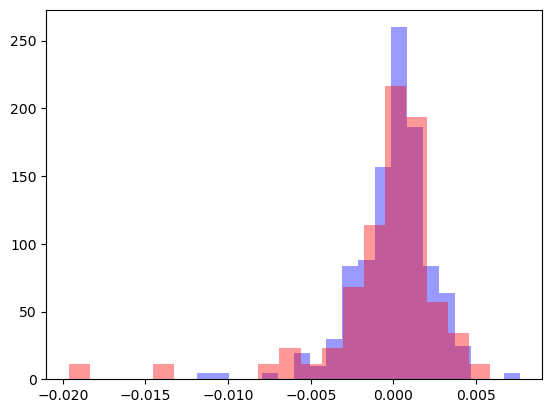

In [121]:
color = {"excitatory": "blue", "inhibitory": "red"}
for interaction in ["excitatory", "inhibitory"]:
    plt.hist(c3po_effects[interaction], bins=20, color=color[interaction], alpha=0.4, density=True)

In [114]:
c3po_effects[interaction]

[Array(0.0007752, dtype=float32),
 Array(0.00154608, dtype=float32),
 Array(0.0002918, dtype=float32),
 Array(0.00011965, dtype=float32),
 Array(-0.00638954, dtype=float32)]

In [107]:
spike_response = (results[:, ind_pre, :].mean(axis=1)- results[:, ind_post, :].mean(axis=1)).mean(axis=0)
spike_response.shape

(20,)

In [109]:


ind_unit_1 = np.where(unit_ids == unit_id_1)[0][0]
z_neuron_1 = z_neuron[ind_unit_1]
# rate_response = np.einsum(
#     "sc,c->s",
#     spike_response,
#     z_neuron_1,
#     optimize=True,
# )
rate_response = spike_response @ z_neuron_1
rate_response

Array(0.00443203, dtype=float32)

Array(0.0007752, dtype=float32)

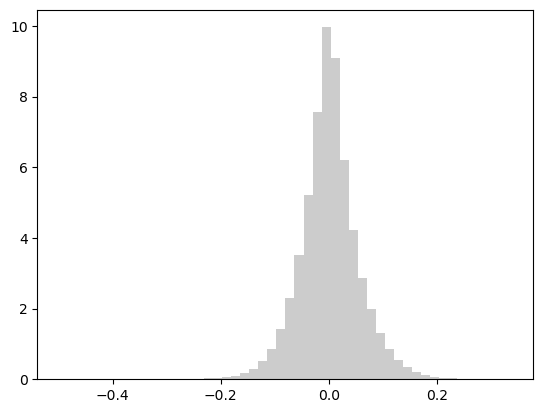

In [98]:
plt.hist(rate_response, bins=50, color="grey", alpha=0.4, density=True)
rate_response.mean()